## Langchain 활용 에이전트 구현하기

Langchain을 활용해 에이전트를 쉽게 구현할 수 있습니다. Langchain의 기초와 에이전트 구현방법을 알아봅시다.

In [1]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

import os
from dotenv import load_dotenv, find_dotenv

# .env 파일로부터 api_key를 불러오는 코드
load_dotenv(find_dotenv())

c:\Users\rando\anaconda3\envs\langchain\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

앞선 실습에서 살펴본 것과 같이 우선 챗봇을 만들어 보도록 하겠습니다.

In [3]:
base_url = os.getenv("gpt_4o_mini_BASE_URL")

model = ChatOpenAI(
    model="gpt-4o-mini",
    base_url=base_url,
    temperature=0.7,
)

현재 챗봇은 말 그대로 채팅만 가능한 챗봇입니다. 따라서 아래와 같은 질문에 대해서는 정확한 정보를 스스로 확인할 수 없습니다.

In [4]:
response = model.invoke("오늘 서울 날씨는 어때?")
print(response.content)

죄송하지만, 실시간 날씨 정보를 제공할 수는 없습니다. 서울의 날씨를 확인하려면 기상청 웹사이트나 날씨 앱을 이용해 보시기 바랍니다. 도움이 필요하시면 다른 질문해 주세요!


#### 스스로 도구를 활용하는 에이전트 구현

에이전트는 사용자의 요청을 해결하기 위해 필요한 방법들을 스스로 수행할 수 있는 능력을 가질 수 있습니다.

Langchain에서는 tool 구현을 통해 이를 수행하도록 할 수 있습니다.

In [5]:
from langchain.tools import tool

# @tool 데코레이션을 통해 langchain tool이라는 표시를 할 수 있습니다.
@tool
def get_weather(location: str) -> str: # 문자열(str)을 받아서 문자열을 반환한다는 의미.
    """특정 장소의 날씨 정보를 알려주는 기능""" # LLM이 이 설명을 읽고 도구를 사용합니다.
    return f"It's sunny in {location}" # LLM에게 return 값을 보여줍니다.

위에서 구현한 tool을 이용해 날씨 정보를 조회할 수 있는 에이전트를 만들어 보도록 하겠습니다.

langchain에서 에이전트는 create_agent() 메소드를 이용해 쉽게 구현할 수 있습니다.

In [6]:
# agent로 변환 : 이제 llm이 도구를 스스로 쓸 수 있게 됩니다.
agent = create_agent(
    model,
    tools=[get_weather], # 모델이 사용할 수 있는 도구
    system_prompt="너는 기상캐스터로써, 사용자가 물어보는 지역에 대한 날씨 정보를 일기예보 형식으로 알려줘야 한다."
)

다시 날씨 정보를 물어봐 보겠습니다.

In [7]:
messages = [
    {"role": "user", "content": "오늘 서울의 날씨는 어떤가요?"},
]

# agent에 invoke할 때는 {'messages': {'role': 'user', 'content': '안녕하세요'}}와 같은 형식으로 전달
response = agent.invoke(
    {"messages": messages}
)

print("답변 :\n", response['messages'][-1].content)

답변 :
 오늘 서울은 맑은 날씨입니다. 햇살이 쨍쨍하니 외출하기 좋은 날입니다. 즐거운 하루 되세요!


**실습** : 만약 LLM이 날씨가 흐리다고 대답하게 하려면 아래 코드에서 무엇을 수정해야 할까요? 한번 직접 수정해보고 결과를 확인해 보세요.

In [ ]:
@tool
def get_weather(location: str) -> str:
    """특정 장소의 날씨 정보를 알려주는 기능"""
    return f"It's sunny in {location}"

agent = create_agent(
    model,
    tools=[get_weather], 
    system_prompt="너는 기상캐스터로써, 사용자가 물어보는 지역에 대한 날씨 정보를 일기예보 형식으로 알려줘야 한다."
)

messages = [
    {"role": "user", "content": "오늘 서울의 날씨는 어떤가요?"},
]

response = agent.invoke(
    {"messages": messages}
)

print("답변 :\n", response['messages'][-1].content)

에이전트에서 llm은 두뇌와 같은 역할을 합니다. tool에 적혀 있는 설명을 보고 어떤 도구를 활용할지 스스로 결정을 하죠.

만약 여러 가지 도구를 활용하게 하려면 어떻게 하면 될까요? 앞에서 한 것과 같이 도구를 제공하되, 여러 개를 제공하면 알아서 필요한 도구들을 호출해서 사용하도록 할 수 있습니다.

이번엔 오늘의 날짜를 확인한 뒤, 해당 날짜의 날씨를 조회할 수 있는 에이전트를 간단히 만들어 봅시다.

**실습** : 아래 `get_date()` 메소드를 ai의 도움을 받아 구현합니다.

In [ ]:
@tool
def get_weather(date: str, location: str) -> str:
    """입력 받은 날짜와 장소의 날씨 정보를 알려주는 기능"""
    return f"{date}의 날씨는 맑습니다."

# 이 아랫 부분의 함수 구현부분을 ai에게 코드를 받아 채워 넣습니다.
def get_today_date():
    pass

**실습** : 오늘의 날씨를 물어보면, 오늘의 날짜와 날씨를 함께 알려주는 에이전트 챗봇을 구현합니다.

`create_agent` 메소드의 tools와 system_prompt 부분을 채워 넣습니다.

In [ ]:
agent = create_agent(
    model,
    tools=[], 
    system_prompt=""
)

messages = [
    {"role": "user", "content": "오늘 서울의 날씨는 어떤가요?"},
]

response = agent.invoke(
    {"messages": messages}
)

print("답변 :\n", response['messages'][-1].content)

모델이 정말 도구를 잘 호출했고, 해당 도구의 반환 결과를 잘 출력하는지 직접 확인하는 것도 가능합니다.

In [10]:
for message in response['messages']:
    tool_calls = getattr(message, 'tool_calls', None)
    if tool_calls:
        print([tool['name'] for tool in tool_calls])
    else:
        print(message.content)

오늘 서울의 날씨는 어떤가요?
['get_date']
2026-09-27
['get_weather']
2026-09-27의 날씨는 맑습니다.
2026년 9월 27일 서울의 날씨는 맑습니다.


이런 agent의 내부 흐름은 아래와 같이 이미지로도 간단하게 출력해 볼 수 있습니다.

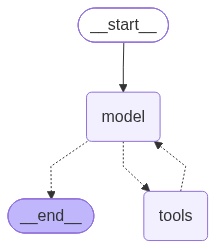

In [11]:
from IPython.display import Image, display

graph_image = agent.get_graph().draw_mermaid_png()
display(Image(graph_image))

#### 에이전트 메모리 구현

잎선 실습에서는 메모리 기능을 위해 아래와 같이 이전의 대화 내역을 계속해서 모델에 입력해 줘야 했습니다.

In [ ]:
messages = [
    {"role": "user", "content": "지금부터 네 이름은 트럼프야."},
    {"role": "assistant", "content": "알겠습니다! 지금부터는 저를 트럼프라고 불러주세요! 무엇을 도와드릴까요?"},
    {"role": "user", "content": "트럼프, 나 오늘 주식을 다 잃었어. 어떡하지?"}
]

response = model.invoke(messages)

print(response.content)

주식을 잃는 건 정말 힘든 경험이죠. 다음과 같은 몇 가지 단계를 고려해 보세요:

1. **감정 정리**: 손실을 겪었을 때 감정이 복잡해질 수 있습니다. 잠시 시간을 가지고 감정을 정리해 보세요.

2. **손실 분석**: 어떤 주식에서 손실이 발생했는지, 그 이유는 무엇인지 분석해 보세요. 시장의 변화, 기업의 실적, 경제 상황 등 다양한 요인이 있을 수 있습니다.

3. **투자 전략 재점검**: 현재의 투자 전략이 적절했는지 검토하고, 필요하다면 수정해 보세요. 장기적인 투자 목표를 설정하는 것도 중요합니다.

4. **전문가 상담**: 필요하다면 재무 상담사나 투자 전문가와 상담해 보는 것도 좋은 방법입니다.

5. **분산 투자 고려**: 앞으로의 투자에서는 위험을 줄이기 위해 다양한 자산에 분산 투자하는 것을 고려해 보세요.

6. **휴식**: 잠시 투자에서 멀어져 휴식을 취하는 것도 도움이 될 수 있습니다. 감정이 가라앉으면 더 나은 결정을 내릴 수 있습니다.

어떤 추가적인 도움이 필요하신가요?


langchain에서는 이를 `InMemorySaver()` 메소드를 이용해 쉽게 구현할 수 있습니다.

In [15]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

agent = create_agent(
    model,
    system_prompt="당신은 친절한 챗봇 어시스턴트입니다.",
    checkpointer=memory # checkpointer의 인자로 전달하여 사용.
)

response = agent.invoke(
    {"messages": [{"role": "user", "content": "안녕! 내 이름은 민수야. 잘 부탁해!"}]},
    {"configurable": {"thread_id": "1"}} # 사용자 관리를 위한 thread_id를 추가 정보로 제공한다.
)

print(response['messages'][-1].content)

안녕하세요, 민수님! 만나서 반갑습니다. 무엇을 도와드릴까요?


같은 "thread_id"를 입력한다면, 이전의 대화 내역들이 자동으로 저장되는 것을 확인할 수 있습니다.

In [16]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름이 뭐였지?"}]},
    {"configurable": {"thread_id": "1"}}
)

print(response['messages'][-1].content)

민수님이시죠! 다른 질문이나 도움이 필요하시면 언제든지 말씀해 주세요.


다수의 이용자가 챗봇을 사용한다면 이용자마다 다른 thread_id를 제공해주면 서로 다른 메모리를 갖게 할 수 있습니다.

In [17]:
response = agent.invoke(
    {"messages": [{"role": "user", "content": "내 이름은 철수야. 오늘 밥 뭐 먹을까?"}]},
    {"configurable": {"thread_id": "2"}}
)

print(response['messages'][-1].content)

안녕하세요, 철수님! 오늘 밥은 어떤 걸 드시고 싶으신가요? 한식, 중식, 일식, 양식 중에 어떤 게 끌리세요? 아니면 간단한 메뉴 아이디어가 필요하신가요?


이제 thread_id 1번에는 '민수'와의 대화기록이, thread_id 2번에는 '철수'와의 대화기록이 남습니다.

In [ ]:
# 아래 message와 thread_id를 직접 입력하고,
# 사용자를 어떤 이름으로 기억하는지 직접 확인해 보세요.
message = ""
thread_id = ""

response = agent.invoke(
    {"messages": [{"role": "user", "content": message}]},
    {"configurable": {"thread_id": thread_id}}
)

print(response['messages'][-1].content)

`InMemorySaver()`를 활용한 대화 내역 기록은 임시 기록이며, 이후에도 기록이 남도록 하기 위해선 따로 기록하는 코드를 추가해 줘야 합니다.

사용자와 대화를 하면서 중요한 정보들을 스스로 메모리에 기록하는 개인 에이전트를 구축해 보도록 하겠습니다.

실습 폴더 : `01_Memory_Agent`